# Análise FINBRA — Despesas por Função das Capitais (2020-2025)

**Desafio técnico — Estágio em Análise de Dados, Sefaz Maceió**

Este notebook representa uma análise preliminar para servir de base para a
criação do relatório final.

## Setup

In [70]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from src.analises import taxa_execucao_media_periodo, melhor_e_pior_funcao, composicao_pareto
from src.estilo_graficos import aplicar_estilo, COR_BASE
from src.graficos import plotar_heatmap_top10, plotar_evolucao, plotar_pareto, plotar_frequencia_funcao

aplicar_estilo()
pd.options.display.float_format = "{:,.2f}".format

CAMINHO_PARQUET = Path("../dados_consolidados/finbra_consolidado.parquet")
CAPITAL = "Maceió"
ANOS_COMPLETOS = [2020, 2021, 2022, 2023, 2024]
FUNCOES_INTERESSE = ["12 - Educação", "10 - Saúde", "06 - Segurança Pública"]

df = pd.read_parquet(CAMINHO_PARQUET)
df_completo = df[df["ano"] != 2025].copy()
print(f"{len(df_completo):,} linhas em 2020-2024, {df_completo['Instituição'].nunique()} capitais")

46,271 linhas em 2020-2024, 26 capitais


## 1 — Top 10 por ano em taxa de execução: Educação, Saúde e Segurança Pública

Heatmap: linhas = capitais que estiveram no top 10 em pelo menos um ano;
colunas = ano; cor/número = posição no ranking daquele ano (1 = melhor).
Mostra a posição real mesmo nos anos em que a capital caiu fora do top 10,
pra deixar visível a movimentação.

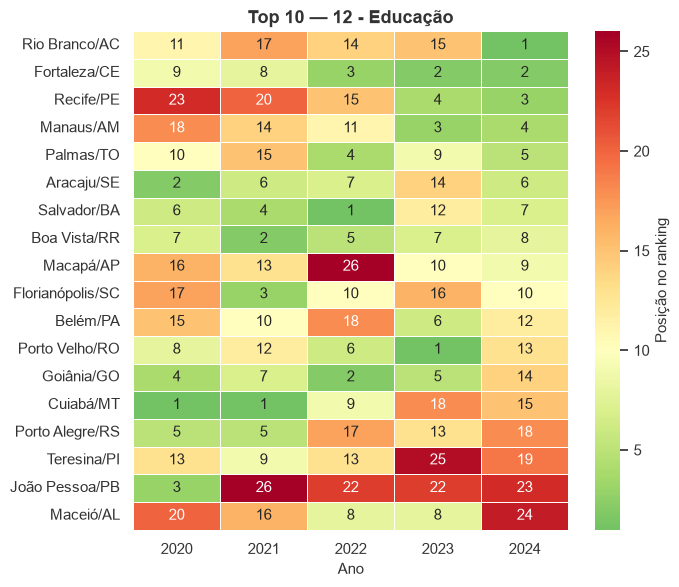

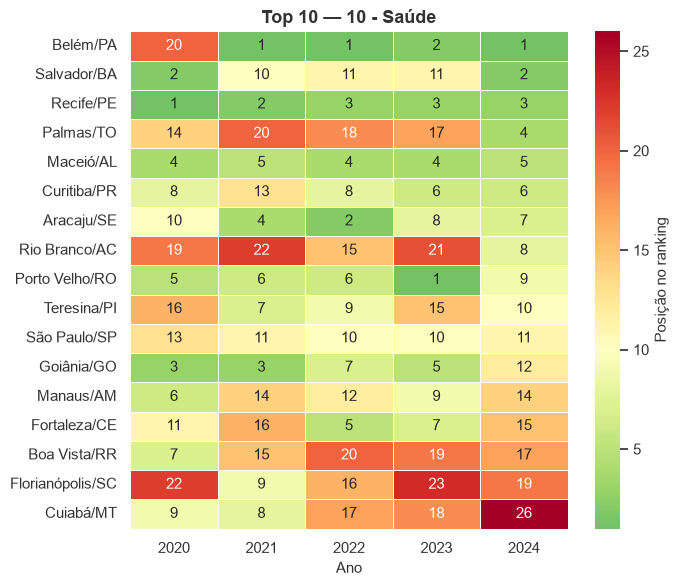

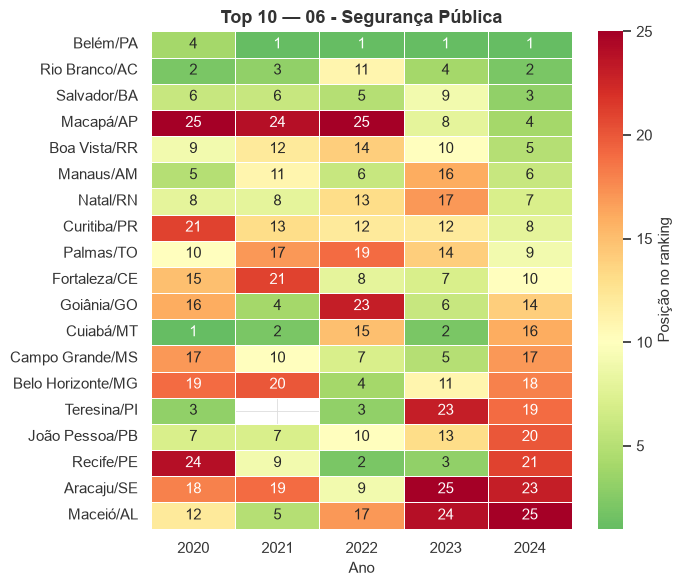

In [71]:
for funcao in FUNCOES_INTERESSE:
    plotar_heatmap_top10(df_completo, conta=funcao, anos=ANOS_COMPLETOS, top_n=10)
    plt.tight_layout()
    plt.show()

### Interpretação dos Gráficos

- Educação: Maceió esteve entre os 10 melhores em 2022 e 2023. Em 2024 foi
  o seu pior desempenho em relação às demais capitais, ficando em 24º.
- Saúde: Maceió se apresenta entre os 10 melhores em todos os anos, com
  certa estabilidade, se mantendo nas 4ª e 5ª colocações.
- Segurança Pública: Maceió ficou entre os 10 primeiros apenas em 2021,
  apresentando uma queda considerável e constante nos anos subsequentes.

**Nota metodológica**: células vazias (NaN) no heatmap significam que a
capital não tem NENHUMA linha reportada para aquela função naquele ano no
FINBRA -- não é erro de cálculo, é ausência do dado na fonte. Ex.: Porto
Velho não reporta "06 - Segurança Pública" em nenhum dos 5 anos (ausência
estrutural); Teresina só falta especificamente em 2021 (buraco pontual).

## 2 — Evolução histórica da taxa de execução: Maceió vs. média das demais

Taxa de Execução ano a ano, Maceió contra a média das outras 25 capitais.
A faixa sombreada mostra o mínimo-máximo das demais — dá pra ver se Maceió
está fora da variação normal ou dentro dela.

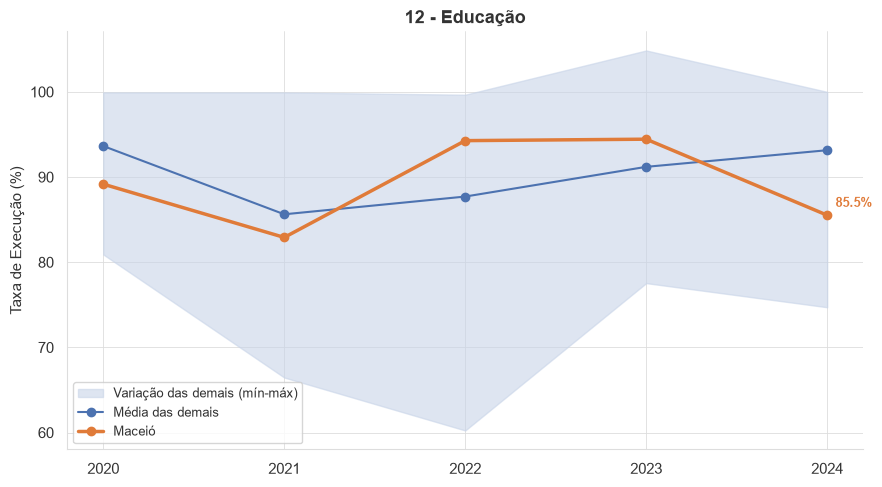

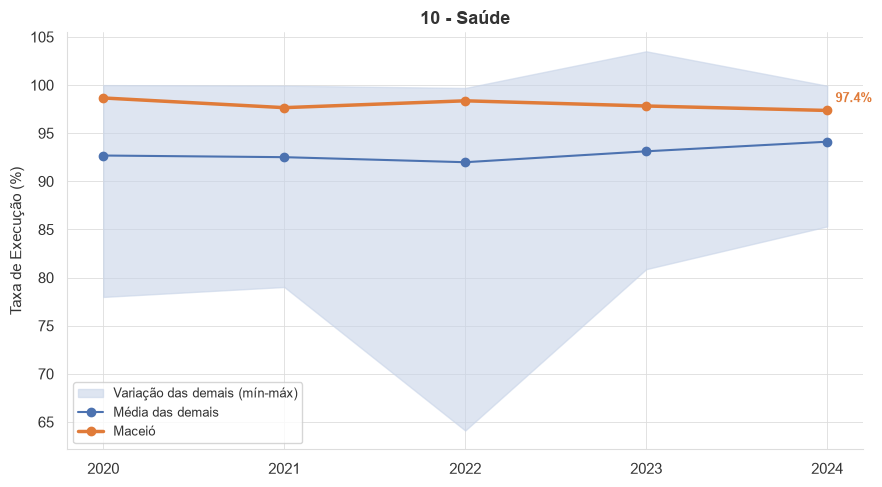

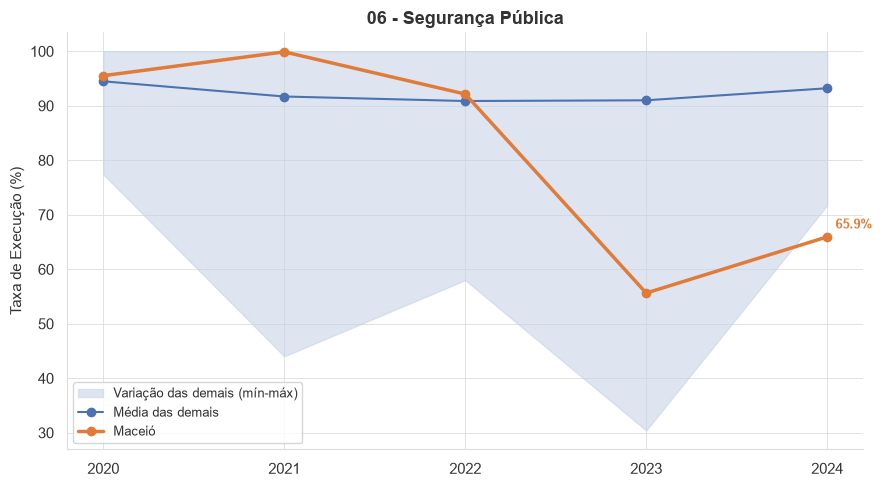

In [72]:
for funcao in FUNCOES_INTERESSE:
    fig, ax = plt.subplots(figsize=(9, 5))
    plotar_evolucao(df_completo, conta=funcao, capital=CAPITAL, anos=ANOS_COMPLETOS, ax=ax)
    ax.legend(loc="lower left", fontsize=9)
    plt.tight_layout()
    plt.show()

### Interpretação dos Gráficos

- Maceió conseguiu se destacar em Saúde, trabalhando acima da média das
  demais capitais em todos os anos, mantendo números superiores a 95%.
- Em Educação a variação é maior. Esteve abaixo da média em 2020 e 2021,
  sendo este o seu pior desempenho, abaixo de 85%. Entretanto, houve uma
  tendência de queda nas demais capitais nesse período, podendo ser
  reflexo da pandemia de Covid-19, seguida de uma grande retomada nos anos
  seguintes. Em 2022 e 2023 esteve acima da média com taxa superior a 90%,
  mas caiu novamente no ano de 2024, contrariando a tendência de alta das
  demais capitais.
- Quanto à Segurança Pública, o desempenho era acima da média entre os
  anos de 2020 e 2022. Entretanto, houve uma queda abrupta em 2023, saindo
  de uma taxa superior a 90% para inferior a 60%. Apesar da retomada em
  2024, Maceió ficou abaixo da variação normal das demais capitais.

**Nota metodológica**: em alguns anos a taxa de execução de "demais capitais"
pode passar de 100%. Isso acontece porque "Despesas Pagas" num ano pode
incluir pagamento de Restos a Pagar de anos anteriores, enquanto "Despesas
Empenhadas" reflete só o empenho do ano corrente — um descompasso de
calendário contábil, não um erro no cálculo.

## 3 — Melhor e pior função de Maceió, e se isso se replica nas demais

Usa a **média 2020-2024** (não um ano isolado) pra não deixar uma oscilação
pontual distorcer o resultado, e um **filtro de materialidade** (só entram
funções com pelo menos 1% do orçamento empenhado médio da capital) — sem
isso, uma função residual poderia "vencer" só por ruído estatístico.

In [73]:
resumo_periodo = taxa_execucao_media_periodo(df_completo, anos=ANOS_COMPLETOS)
melhor_pior = melhor_e_pior_funcao(resumo_periodo, limiar_participacao=0.01)

linha_maceio = melhor_pior[melhor_pior["Instituição"].str.contains(CAPITAL)].iloc[0]
print(f"{CAPITAL}:")
print(f"  Melhor função: {linha_maceio['melhor_funcao']} ({linha_maceio['melhor_taxa']:.1%})")
print(f"  Pior função:   {linha_maceio['pior_funcao']} ({linha_maceio['pior_taxa']:.1%})")

Maceió:
  Melhor função: 09 - Previdência Social (99.9%)
  Pior função:   15 - Urbanismo (80.7%)


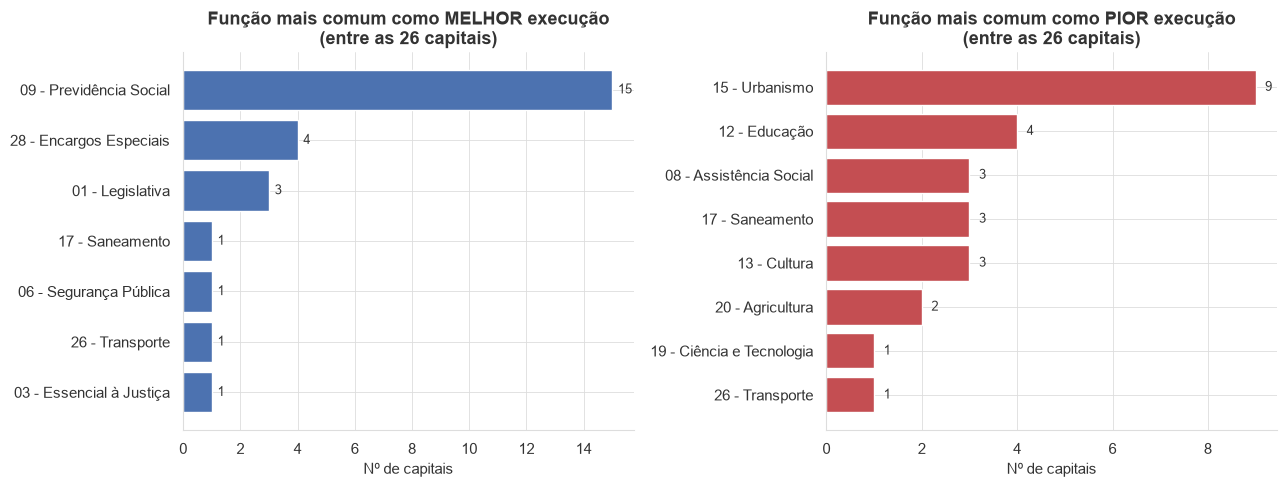

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contagem_melhor = melhor_pior["melhor_funcao"].value_counts().head(8)
plotar_frequencia_funcao(contagem_melhor, "Função mais comum como MELHOR execução\n(entre as 26 capitais)", COR_BASE, ax=axes[0])

contagem_pior = melhor_pior["pior_funcao"].value_counts().head(8)
plotar_frequencia_funcao(contagem_pior, "Função mais comum como PIOR execução\n(entre as 26 capitais)", "#c44e52", ax=axes[1])

plt.tight_layout()
plt.show()

### Interpretação dos Gráficos

- Maceió teve como melhor função a Previdência Social, com quase 100% de
  execução. Essa mesma função se apresenta como a melhor desempenhada em
  15 das 26 capitais, ou seja, mais da metade das capitais.
- Quanto ao pior desempenho, está na função de Urbanismo, com cerca de
  80% de execução. Urbanismo se apresenta como pior desempenho em 9 das
  26 capitais, sendo a função mais comum em termos de piores desempenhos.

## 4 — Distribuição dos valores empenhados por função (Maceió)

Gráfico de Pareto: barras = % do total empenhado por função; linha = %
acumulado. Mostra o quanto o orçamento está concentrado em poucas funções.

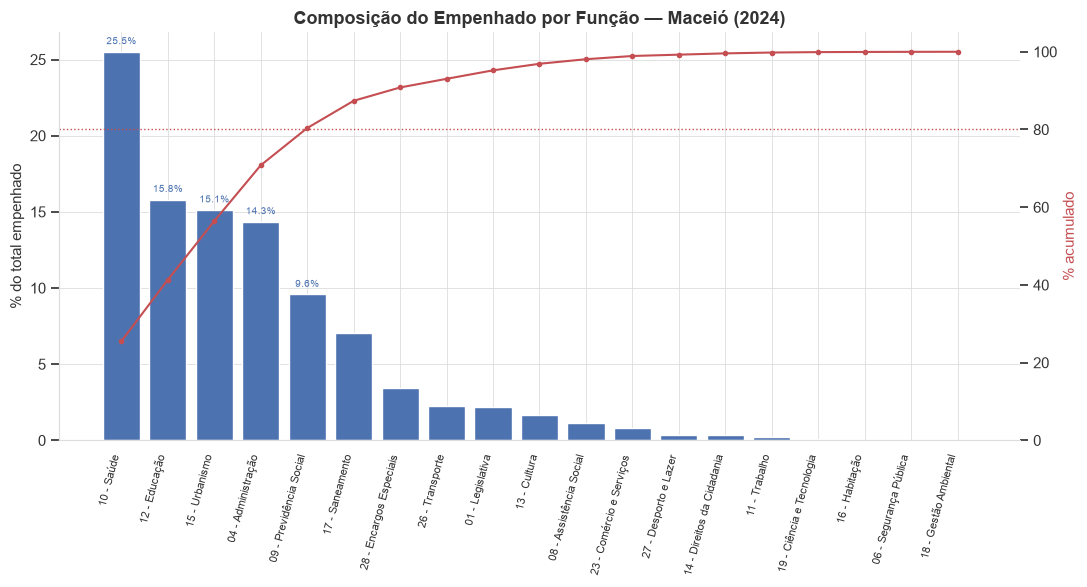

5 de 19 funções concentram 80% do orçamento empenhado.


In [75]:
ANO_COMPOSICAO = 2024

pareto_funcoes = composicao_pareto(df_completo, capital=CAPITAL, ano=ANO_COMPOSICAO, nivel="funcao")

fig, ax = plt.subplots(figsize=(11, 6))
plotar_pareto(pareto_funcoes, f"Composição do Empenhado por Função — {CAPITAL} ({ANO_COMPOSICAO})", ax=ax)
plt.tight_layout()
plt.show()

n_80 = (pareto_funcoes["percentual_acumulado"] <= 80).sum() + 1
print(f"{n_80} de {len(pareto_funcoes)} funções concentram 80% do orçamento empenhado.")

### Interpretação dos Gráficos

- Saúde, Educação, Urbanismo, Administração e Previdência Social formam
  80% dos valores empenhados por Maceió, considerando o ano de 2024.
  Saúde e Educação são funções essenciais e direitos fundamentais, sendo
  totalmente compatíveis com os seus posicionamentos na distribuição.
  Curiosamente, Urbanismo, embora tenha uma das taxas de execução mais
  baixas, está posicionado atrás apenas da Educação.

## 5 — Distribuição das subfunções de Saúde e Educação

Mesmo formato de Pareto, agora um nível mais fundo: dentro de Saúde e
Educação, pra onde vai o dinheiro?

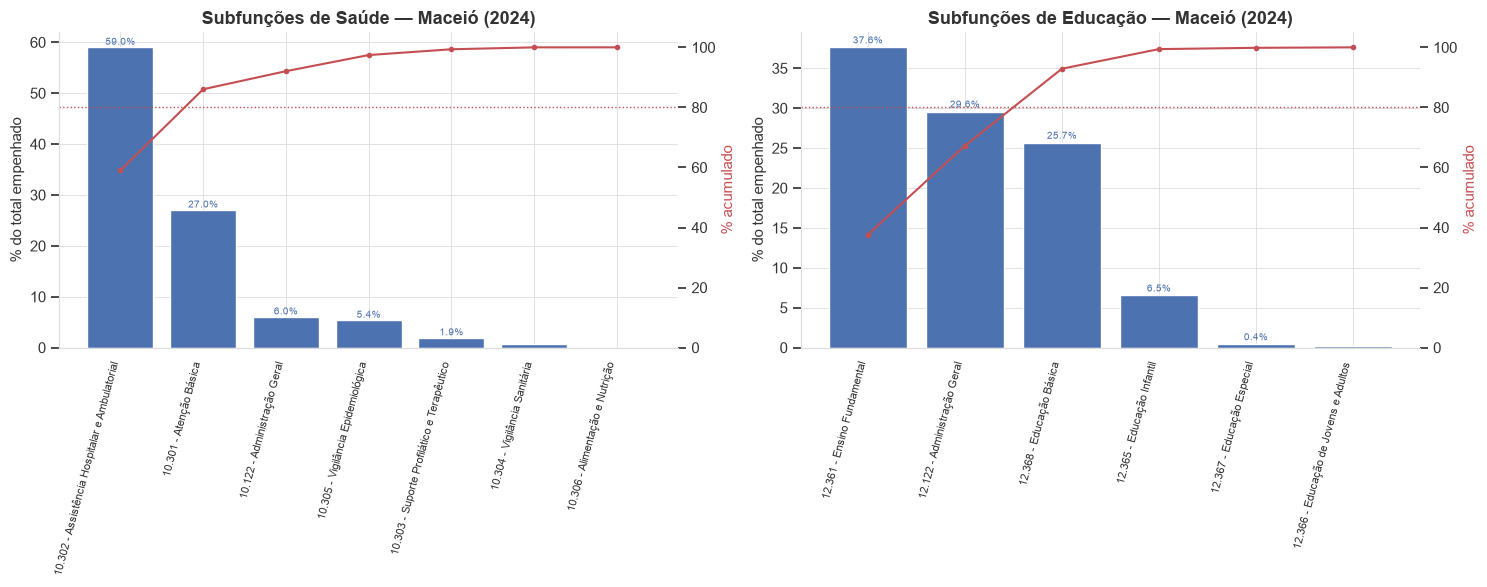

Saúde: 2 de 7 subfunções concentram 80%+ do total da função.
Educação: 3 de 6 subfunções concentram 80%+ do total da função.


In [76]:
pareto_saude = composicao_pareto(df_completo, capital=CAPITAL, ano=ANO_COMPOSICAO, nivel="subfuncao", filtro_conta="10")
pareto_educacao = composicao_pareto(df_completo, capital=CAPITAL, ano=ANO_COMPOSICAO, nivel="subfuncao", filtro_conta="12")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plotar_pareto(pareto_saude, f"Subfunções de Saúde — {CAPITAL} ({ANO_COMPOSICAO})", ax=axes[0])
plotar_pareto(pareto_educacao, f"Subfunções de Educação — {CAPITAL} ({ANO_COMPOSICAO})", ax=axes[1])
plt.tight_layout()
plt.show()

n_80_saude = (pareto_saude["percentual_acumulado"] <= 80).sum() + 1
n_80_edu = (pareto_educacao["percentual_acumulado"] <= 80).sum() + 1
print(f"Saúde: {n_80_saude} de {len(pareto_saude)} subfunções concentram 80%+ do total da função.")
print(f"Educação: {n_80_edu} de {len(pareto_educacao)} subfunções concentram 80%+ do total da função.")

### Interpretação dos Gráficos

- Assistência Hospitalar e Ambulatorial, bem como Atenção Básica, formam
  cerca de 86% dos valores empenhados para a função de Saúde da capital
  de Maceió em 2024. Valores considerados normais, tendo em vista a
  importância dessas subfunções para a sociedade.
- Quanto à Educação, as subfunções referentes a Ensino Fundamental,
  Administração Geral e Educação Básica formam cerca de 93% dos valores
  empenhados em 2024, sendo seguidas pela Educação Infantil.